In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# RIGOROUS STATISTICAL ANALYSIS
# - Welch's t-test
# - Cohen's d Effect Size
# - Hedges' g
# - 95% Confidence Interval
# - Multiple Testing Correction
#     * FDR (Benjamini-Hochberg)
#     * Bonferroni
#     * Holm
# - Save Full Results
# ═══════════════════════════════════════════════════════════════════════

from itertools import combinations
from scipy.stats import ttest_ind, t
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests

# ═══════════════════════════════════════════════════════════════════════
# RESULTS
# ═══════════════════════════════════════════════════════════════════════

results = {
    "baseline CNN with original": [0.992860,0.991456,0.982678,0.995318,0.993797,0.993095,0.961493,0.995435,0.994265,0.994382],

    "baseline CNN with Oversampling": [0.996128,0.997118,0.996037,0.991895,0.997388,0.996668,0.993696,0.996128,0.994777,0.986401],

    "baseline CNN with Undersampling": [0.990352,0.989107,0.992375,0.991597,0.852163,0.989574,0.988017,0.990196,0.978992,0.985839],

    "CNN_LSTM with original": [0.984399,0.968799,0.987520,0.981279,0.967239,0.979719,0.976599,0.976599,0.973479,0.973479],

    "CNN_LSTM with Oversampling": [0.985594,0.977191,0.986795,0.986795,0.987995,0.987995,0.986795,0.983193,0.986795,0.985594],

    "CNN_LSTM with undersampling": [0.995851,0.995851,0.995851,0.993776,0.995851,0.995851,0.995851,0.995851,0.995851,0.995851],

    "Mobilenet v2 with original": [0.976826,0.977645,0.978464,0.976592,0.985019,0.978464,0.981156,0.978230,0.978581,0.977060],

    "Mobilenet v2 with oversampling": [0.984600,0.985411,0.984510,0.984150,0.980457,0.983429,0.982529,0.983429,0.981178,0.984420],

    "Mobilenet v2 with undersampling": [0.969966,0.967009,0.965297,0.969032,0.971366,0.971366,0.966698,0.971366,0.971833,0.969655]
}

# ═══════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════

# Cohen's d
def cohens_d(x, y):

    x = np.array(x)
    y = np.array(y)

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        (
            ((nx - 1) * np.var(x, ddof=1)) +
            ((ny - 1) * np.var(y, ddof=1))
        ) / (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std


# Hedges' g (bias-corrected Cohen's d)
def hedges_g(x, y):

    d = cohens_d(x, y)

    nx = len(x)
    ny = len(y)

    correction = 1 - (3 / (4*(nx + ny) - 9))

    return d * correction


# Effect size interpretation
def interpret_effect_size(d):

    ad = abs(d)

    if ad < 0.2:
        return "Negligible"
    elif ad < 0.5:
        return "Small"
    elif ad < 0.8:
        return "Medium"
    else:
        return "Large"


# 95% Confidence Interval using standard error
def confidence_interval(data, confidence=0.95):

    data = np.array(data)

    n = len(data)
    mean = np.mean(data)
    sem = np.std(data, ddof=1) / np.sqrt(n)

    h = sem * t.ppf((1 + confidence) / 2., n-1)

    return mean - h, mean + h


# ═══════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════

summary_rows = []

for model_name, scores in results.items():

    scores = np.array(scores)

    mean_acc = np.mean(scores)
    std_acc = np.std(scores, ddof=1)

    ci_low, ci_high = confidence_interval(scores)

    summary_rows.append({

        "Model": model_name,

        "Mean Accuracy": round(mean_acc, 6),

        "Std": round(std_acc, 6),

        "95% CI Lower": round(ci_low, 6),

        "95% CI Upper": round(ci_high, 6),

        "CI Method": "t-based CI using standard error"

    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(summary_df)

# ═══════════════════════════════════════════════════════════════════════
# PAIRWISE COMPARISONS
# ═══════════════════════════════════════════════════════════════════════

rows = []
p_values = []

comparisons = list(combinations(results.items(), 2))

for (model1, scores1), (model2, scores2) in comparisons:

    # Welch's t-test
    t_stat, p_val = ttest_ind(
        scores1,
        scores2,
        equal_var=False
    )

    # Effect sizes
    d = cohens_d(scores1, scores2)
    g = hedges_g(scores1, scores2)

    # Mean difference
    mean_diff = np.mean(scores1) - np.mean(scores2)

    rows.append({

        "Model Comparison": f"{model1} vs {model2}",

        "Mean Difference": mean_diff,

        "t-statistic": t_stat,

        "Raw p-value": p_val,

        "Cohen_d": d,

        "Hedges_g": g,

        "Effect Size Interpretation": interpret_effect_size(d)

    })

    p_values.append(p_val)

# ═══════════════════════════════════════════════════════════════════════
# MULTIPLE TESTING CORRECTIONS
# ═══════════════════════════════════════════════════════════════════════

# FDR (Benjamini-Hochberg)
reject_fdr, pvals_fdr, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'
)

# Bonferroni
reject_bonf, pvals_bonf, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='bonferroni'
)

# Holm
reject_holm, pvals_holm, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='holm'
)

# ═══════════════════════════════════════════════════════════════════════
# ADD CORRECTIONS TO TABLE
# ═══════════════════════════════════════════════════════════════════════

for i in range(len(rows)):

    rows[i]["FDR Corrected p"] = pvals_fdr[i]
    rows[i]["Significant (FDR)"] = reject_fdr[i]

    rows[i]["Bonferroni Corrected p"] = pvals_bonf[i]
    rows[i]["Significant (Bonferroni)"] = reject_bonf[i]

    rows[i]["Holm Corrected p"] = pvals_holm[i]
    rows[i]["Significant (Holm)"] = reject_holm[i]

# ═══════════════════════════════════════════════════════════════════════
# CREATE FINAL DATAFRAME
# ═══════════════════════════════════════════════════════════════════════

df = pd.DataFrame(rows)

# Rounding
numeric_cols = [
    "Mean Difference",
    "t-statistic",
    "Raw p-value",
    "FDR Corrected p",
    "Bonferroni Corrected p",
    "Holm Corrected p",
    "Cohen_d",
    "Hedges_g"
]

for col in numeric_cols:
    df[col] = df[col].astype(float).round(6)

# ═══════════════════════════════════════════════════════════════════════
# DISPLAY
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PAIRWISE STATISTICAL COMPARISONS")
print("="*80)

print(df)

# ═══════════════════════════════════════════════════════════════════════
# SAVE TO EXCEL
# ═══════════════════════════════════════════════════════════════════════

with pd.ExcelWriter("rigorous_statistical_analysis.xlsx") as writer:

    summary_df.to_excel(
        writer,
        sheet_name="Summary_Statistics",
        index=False
    )

    df.to_excel(
        writer,
        sheet_name="Pairwise_Comparisons",
        index=False
    )

print("\n✅ Saved Successfully:")
print("   rigorous_statistical_analysis.xlsx")

# ═══════════════════════════════════════════════════════════════════════
# OPTIONAL: SAVE CSV
# ═══════════════════════════════════════════════════════════════════════

summary_df.to_csv(
    "summary_statistics.csv",
    index=False
)

df.to_csv(
    "pairwise_comparisons.csv",
    index=False
)

print("✅ CSV files saved successfully")


SUMMARY STATISTICS
                             Model  Mean Accuracy       Std  95% CI Lower  \
0       baseline CNN with original       0.989478  0.010504      0.981964   
1   baseline CNN with Oversampling       0.994624  0.003342      0.992233   
2  baseline CNN with Undersampling       0.974821  0.043265      0.943871   
3           CNN_LSTM with original       0.976911  0.006487      0.972271   
4       CNN_LSTM with Oversampling       0.985474  0.003224      0.983168   
5      CNN_LSTM with undersampling       0.995644  0.000656      0.995174   
6       Mobilenet v2 with original       0.978804  0.002538      0.976988   
7   Mobilenet v2 with oversampling       0.983411  0.001587      0.982276   
8  Mobilenet v2 with undersampling       0.969359  0.002306      0.967709   

   95% CI Upper                        CI Method  
0      0.996992  t-based CI using standard error  
1      0.997014  t-based CI using standard error  
2      1.005771  t-based CI using standard error  
3    

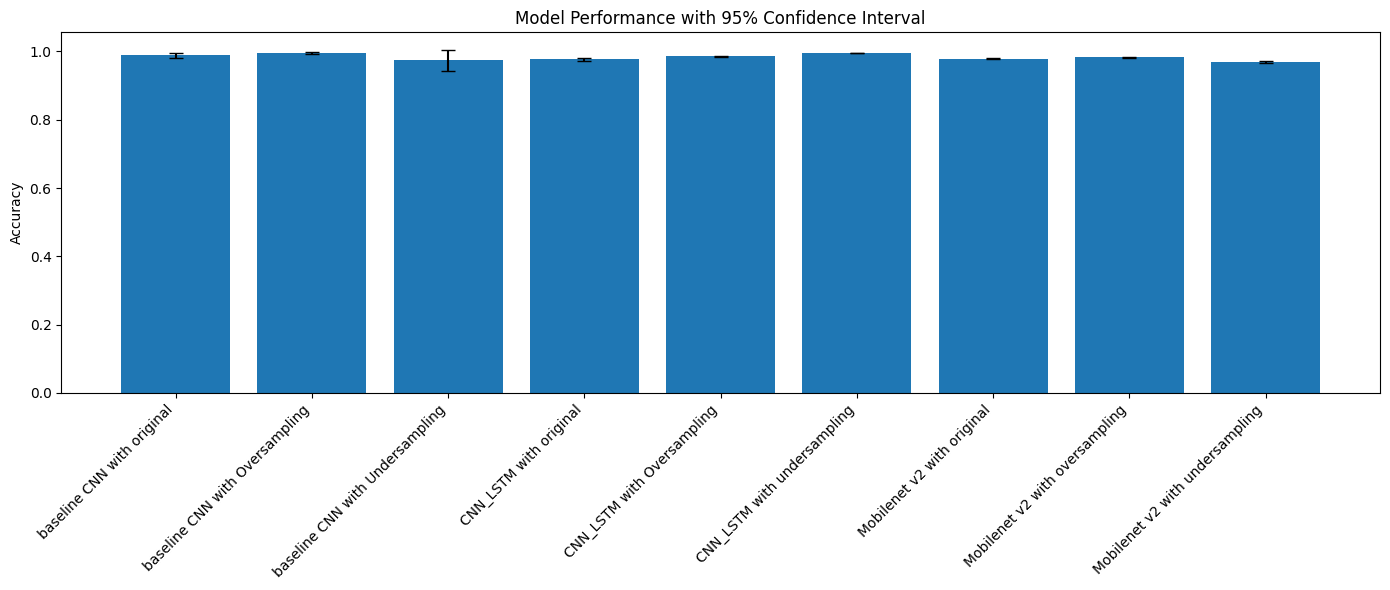

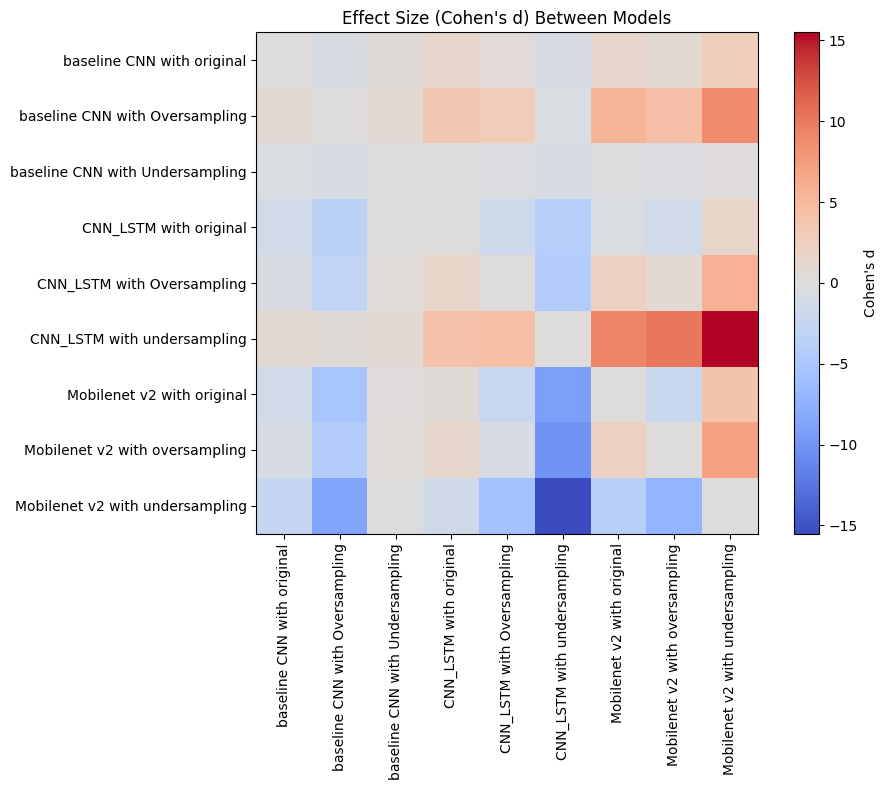

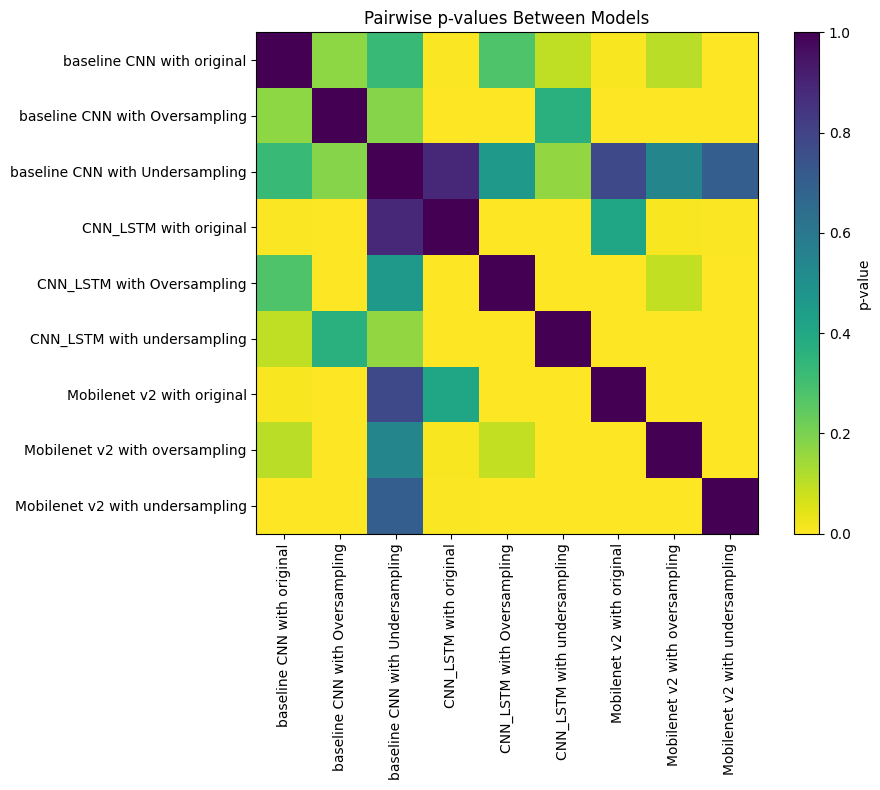

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ═════════════════════════════════════
# 1) BAR PLOT: Mean Accuracy + CI
# ═════════════════════════════════════

plt.figure(figsize=(14,6))

x = summary_df["Model"]
y = summary_df["Mean Accuracy"]
yerr = [
    summary_df["Mean Accuracy"] - summary_df["95% CI Lower"],
    summary_df["95% CI Upper"] - summary_df["Mean Accuracy"]
]

plt.bar(x, y, yerr=yerr, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Performance with 95% Confidence Interval")
plt.tight_layout()
plt.show()


# ═════════════════════════════════════
# 2) HEATMAP: Cohen's d (Effect Size Matrix)
# ═════════════════════════════════════

models = list(results.keys())
n = len(models)

effect_matrix = np.zeros((n, n))

for i, (m1, s1) in enumerate(results.items()):
    for j, (m2, s2) in enumerate(results.items()):
        if i != j:
            effect_matrix[i, j] = cohens_d(s1, s2)

plt.figure(figsize=(10,8))
plt.imshow(effect_matrix, cmap='coolwarm')
plt.colorbar(label="Cohen's d")

plt.xticks(range(n), models, rotation=90)
plt.yticks(range(n), models)

plt.title("Effect Size (Cohen's d) Between Models")
plt.tight_layout()
plt.show()


# ═════════════════════════════════════
# 3) HEATMAP: p-values (Pairwise significance)
# ═════════════════════════════════════

p_matrix = np.ones((n, n))

idx = 0
for i in range(n):
    for j in range(i+1, n):
        p_matrix[i, j] = p_values[idx]
        p_matrix[j, i] = p_values[idx]
        idx += 1

plt.figure(figsize=(10,8))
plt.imshow(p_matrix, cmap='viridis_r')
plt.colorbar(label="p-value")

plt.xticks(range(n), models, rotation=90)
plt.yticks(range(n), models)

plt.title("Pairwise p-values Between Models")
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# RIGOROUS STATISTICAL ANALYSIS (UPDATED)
# - Welch's t-test
# - Cohen's d
# - Hedges' g
# - t-based Confidence Interval
# - Bootstrap Confidence Interval (5,000 resamples)
# - Multiple Testing Correction (FDR, Bonferroni, Holm)
# ═══════════════════════════════════════════════════════════════════════

from itertools import combinations
import numpy as np
import pandas as pd
import math
from scipy.stats import ttest_ind, t
from statsmodels.stats.multitest import multipletests


# ═══════════════════════════════════════════════════════════════════════
# DATA
# ═══════════════════════════════════════════════════════════════════════

results = {
    "baseline CNN with original": [0.992860,0.991456,0.982678,0.995318,0.993797,0.993095,0.961493,0.995435,0.994265,0.994382],
    "baseline CNN with Oversampling": [0.996128,0.997118,0.996037,0.991895,0.997388,0.996668,0.993696,0.996128,0.994777,0.986401],
    "baseline CNN with Undersampling": [0.990352,0.989107,0.992375,0.991597,0.852163,0.989574,0.988017,0.990196,0.978992,0.985839],

    "CNN_LSTM with original": [0.984399,0.968799,0.987520,0.981279,0.967239,0.979719,0.976599,0.976599,0.973479,0.973479],
    "CNN_LSTM with Oversampling": [0.985594,0.977191,0.986795,0.986795,0.987995,0.987995,0.986795,0.983193,0.986795,0.985594],
    "CNN_LSTM with undersampling": [0.995851,0.995851,0.995851,0.993776,0.995851,0.995851,0.995851,0.995851,0.995851,0.995851],

    "Mobilenet v2 with original": [0.976826,0.977645,0.978464,0.976592,0.985019,0.978464,0.981156,0.978230,0.978581,0.977060],
    "Mobilenet v2 with oversampling": [0.984600,0.985411,0.984510,0.984150,0.980457,0.983429,0.982529,0.983429,0.981178,0.984420],
    "Mobilenet v2 with undersampling": [0.969966,0.967009,0.965297,0.969032,0.971366,0.971366,0.966698,0.971366,0.971833,0.969655]
}


# ═══════════════════════════════════════════════════════════════════════
# EFFECT SIZE
# ═══════════════════════════════════════════════════════════════════════

def cohens_d(x, y):

    x = np.array(x)
    y = np.array(y)

    nx, ny = len(x), len(y)

    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) +
         (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std


def hedges_g(d, nx, ny):
    correction = 1 - (3 / (4*(nx + ny) - 9))
    return d * correction


def interpret_effect(d):

    ad = abs(d)

    if ad < 0.2:
        return "Negligible"
    elif ad < 0.5:
        return "Small"
    elif ad < 0.8:
        return "Medium"
    else:
        return "Large"


# ═══════════════════════════════════════════════════════════════════════
# CONFIDENCE INTERVALS (UPDATED)
# ═══════════════════════════════════════════════════════════════════════

# t-based CI
def t_ci(data):

    data = np.array(data)
    n = len(data)

    mean = np.mean(data)
    sem = np.std(data, ddof=1) / np.sqrt(n)

    t_val = t.ppf(0.975, df=n-1)

    return mean - t_val * sem, mean + t_val * sem


# Bootstrap CI (REVIEWER STRONG METHOD)
def bootstrap_ci(data, n_boot=5000):

    data = np.array(data)
    boot_means = []

    for _ in range(n_boot):

        sample = np.random.choice(
            data,
            size=len(data),
            replace=True
        )

        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, 2.5)
    upper = np.percentile(boot_means, 97.5)

    return lower, upper


# ═══════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════

summary_rows = []

for model_name, scores in results.items():

    scores = np.array(scores)

    mean = np.mean(scores)
    std = np.std(scores, ddof=1)

    # CI methods
    t_low, t_high = t_ci(scores)
    b_low, b_high = bootstrap_ci(scores)

    summary_rows.append({

        "Model": model_name,
        "Mean Accuracy": round(mean, 6),
        "Std": round(std, 6),

        "CI (t-based)":
            f"[{t_low:.4f}, {t_high:.4f}]",

        "CI (bootstrap)":
            f"[{b_low:.4f}, {b_high:.4f}]",

        "CI Method":
            "t-distribution + bootstrap (5000 resamples)",

    })

summary_df = pd.DataFrame(summary_rows)


# ═══════════════════════════════════════════════════════════════════════
# PAIRWISE STATISTICS
# ═══════════════════════════════════════════════════════════════════════

rows = []
p_values = []

comparisons = list(combinations(results.items(), 2))

for (m1, s1), (m2, s2) in comparisons:

    s1 = np.array(s1)
    s2 = np.array(s2)

    # Welch t-test
    t_stat, p_val = ttest_ind(s1, s2, equal_var=False)

    # Effect sizes
    d = cohens_d(s1, s2)
    g = hedges_g(d, len(s1), len(s2))

    rows.append({

        "Comparison": f"{m1} vs {m2}",
        "Mean Difference": np.mean(s1) - np.mean(s2),
        "t-statistic": t_stat,
        "p-value": p_val,
        "Cohen_d": d,
        "Hedges_g": g,
        "Effect Interpretation": interpret_effect(d)

    })

    p_values.append(p_val)


# Multiple testing correction
reject_fdr, p_fdr, _, _ = multipletests(p_values, method='fdr_bh')
reject_bonf, p_bonf, _, _ = multipletests(p_values, method='bonferroni')
reject_holm, p_holm, _, _ = multipletests(p_values, method='holm')


for i in range(len(rows)):

    rows[i]["FDR p"] = p_fdr[i]
    rows[i]["Bonferroni p"] = p_bonf[i]
    rows[i]["Holm p"] = p_holm[i]

    rows[i]["FDR Significant"] = reject_fdr[i]
    rows[i]["Bonferroni Significant"] = reject_bonf[i]
    rows[i]["Holm Significant"] = reject_holm[i]


df = pd.DataFrame(rows)


# ═══════════════════════════════════════════════════════════════════════
# OUTPUT
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*90)
print("SUMMARY STATISTICS")
print("="*90)
print(summary_df)

print("\n" + "="*90)
print("PAIRWISE STATISTICAL COMPARISONS")
print("="*90)
print(df)


# ═══════════════════════════════════════════════════════════════════════
# SAVE FILES
# ═══════════════════════════════════════════════════════════════════════

with pd.ExcelWriter("rigorous_statistical_analysis_FINAL.xlsx") as writer:

    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    df.to_excel(writer, sheet_name="Pairwise", index=False)

summary_df.to_csv("summary.csv", index=False)
df.to_csv("pairwise.csv", index=False)


print("\n✅ FINAL ANALYSIS COMPLETE")
print("✔ t-CI + Bootstrap-CI")
print("✔ Welch + Effect sizes")
print("✔ Multiple testing corrections")


SUMMARY STATISTICS
                             Model  Mean Accuracy       Std      CI (t-based)  \
0       baseline CNN with original       0.989478  0.010504  [0.9820, 0.9970]   
1   baseline CNN with Oversampling       0.994624  0.003342  [0.9922, 0.9970]   
2  baseline CNN with Undersampling       0.974821  0.043265  [0.9439, 1.0058]   
3           CNN_LSTM with original       0.976911  0.006487  [0.9723, 0.9816]   
4       CNN_LSTM with Oversampling       0.985474  0.003224  [0.9832, 0.9878]   
5      CNN_LSTM with undersampling       0.995644  0.000656  [0.9952, 0.9961]   
6       Mobilenet v2 with original       0.978804  0.002538  [0.9770, 0.9806]   
7   Mobilenet v2 with oversampling       0.983411  0.001587  [0.9823, 0.9845]   
8  Mobilenet v2 with undersampling       0.969359  0.002306  [0.9677, 0.9710]   

     CI (bootstrap)                                    CI Method  
0  [0.9827, 0.9941]  t-distribution + bootstrap (5000 resamples)  
1  [0.9925, 0.9963]  t-distribution

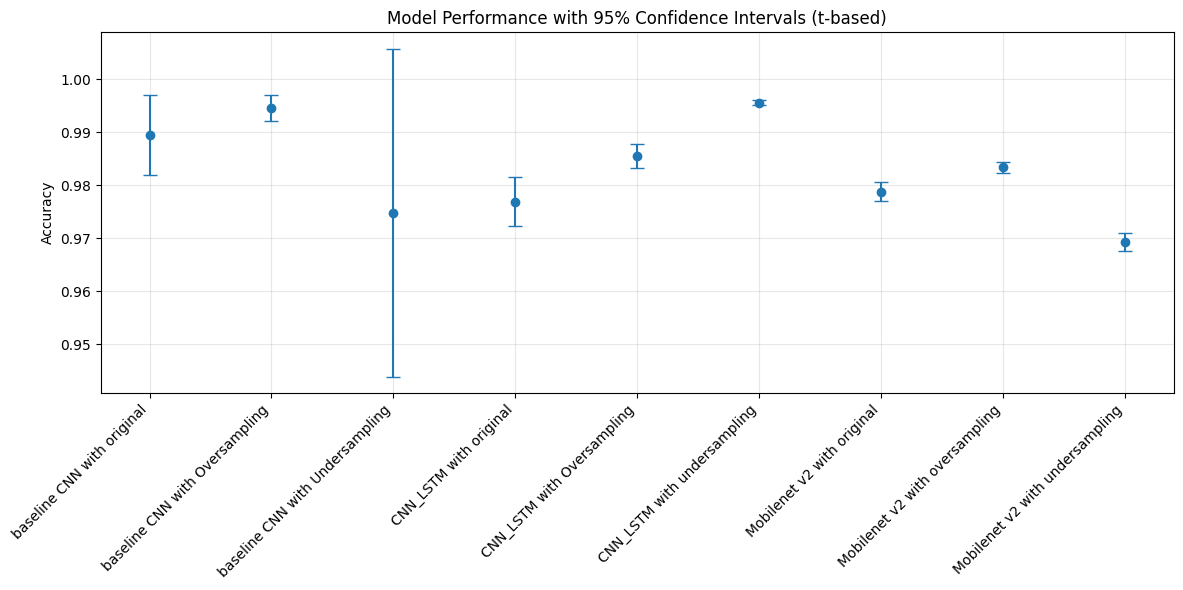

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = summary_df["Model"]
means = summary_df["Mean Accuracy"]

# نحسب error bars من t-CI
t_lowers = []
t_uppers = []

for ci in summary_df["CI (t-based)"]:
    low, high = eval(ci)  # نحول string tuple
    t_lowers.append(low)
    t_uppers.append(high)

lower_err = means - np.array(t_lowers)
upper_err = np.array(t_uppers) - means

plt.figure(figsize=(12,6))

plt.errorbar(
    models,
    means,
    yerr=[lower_err, upper_err],
    fmt='o',
    capsize=5
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Performance with 95% Confidence Intervals (t-based)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

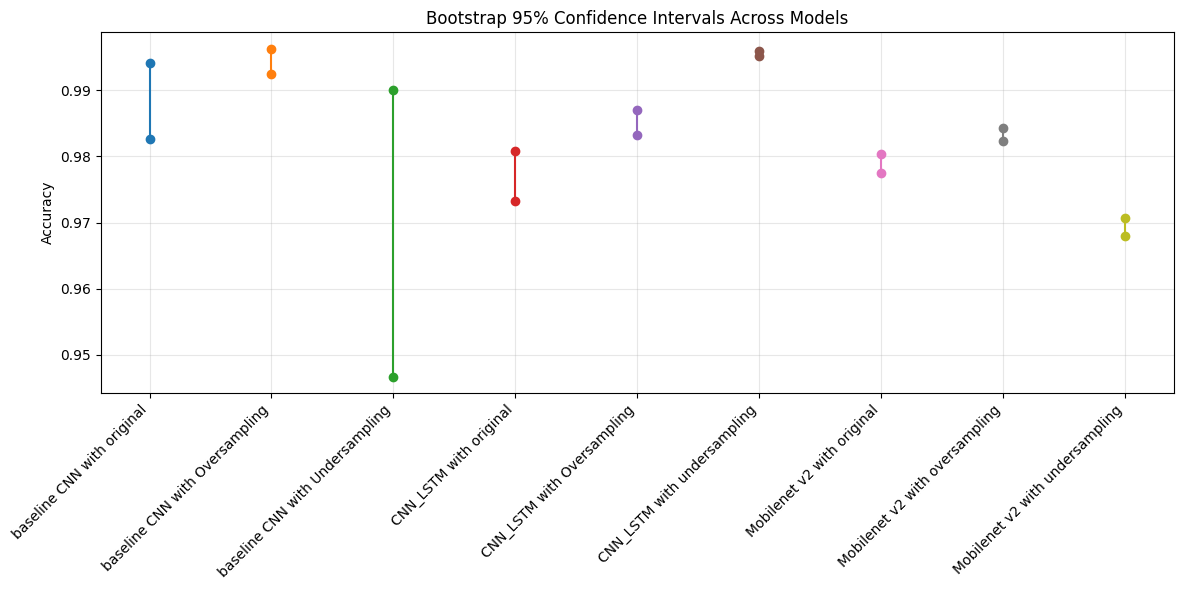

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i, row in summary_df.iterrows():
    low, high = eval(row["CI (bootstrap)"])
    plt.plot([i, i], [low, high], marker='o')

plt.xticks(range(len(summary_df)), summary_df["Model"], rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Bootstrap 95% Confidence Intervals Across Models")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

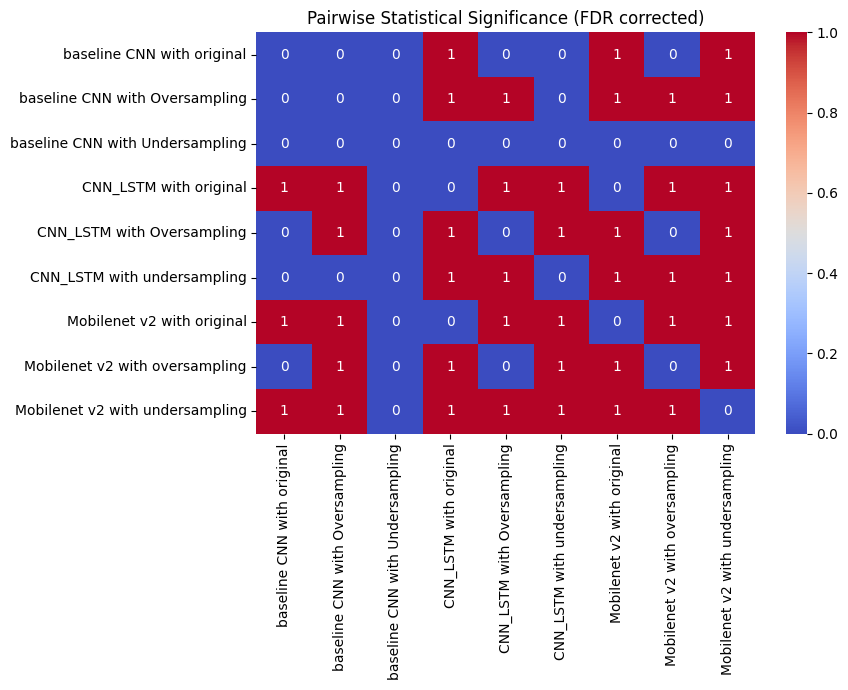

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = list(results.keys())

# مصفوفة numeric (0 = not significant, 1 = significant)
sig_matrix = pd.DataFrame(
    0.0,
    index=models,
    columns=models
)

for _, row in df.iterrows():
    m1, m2 = row["Comparison"].split(" vs ")

    sig = 1.0 if row["FDR Significant"] else 0.0

    sig_matrix.loc[m1, m2] = sig
    sig_matrix.loc[m2, m1] = sig

plt.figure(figsize=(9,7))

sns.heatmap(
    sig_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    cbar=True
)

plt.title("Pairwise Statistical Significance (FDR corrected)")
plt.tight_layout()
plt.show()